# Exercise 6 - Decision Trees

In this exercise we will implement a decision tree classifier and evaluate its performance.

In the event of a persistent problem, do not hesitate to contact the course instructor under

- maurice.wenig@uni-jena.de

### Submission
- Deadline of submission: 08.06.2026 23:59
- Submission on [moodle page](https://moodle.uni-jena.de/course/view.php?id=76636)


# Dataset

Here we will use a synthetic dataset for binary classification created with scikit learn (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)).

### Task 1

Load and display the data located in `X.npy` and `y.npy`.

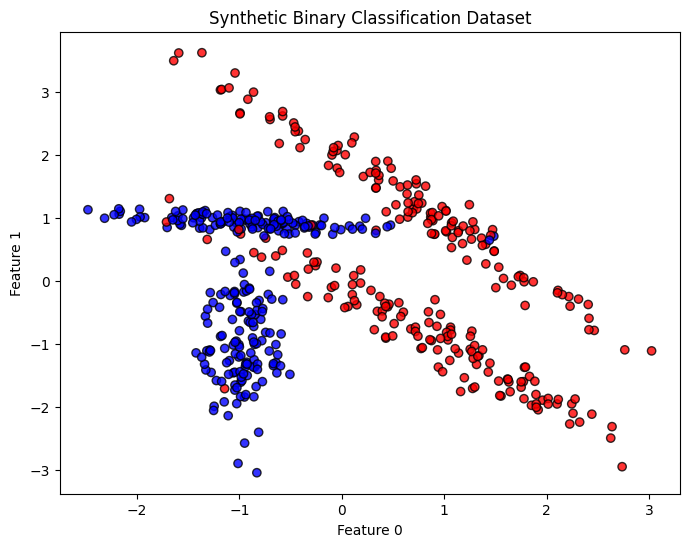

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the features and labels from the provided numpy files
X = np.load('X.npy')
y = np.load('y.npy')

# Visualize the dataset using a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.8)
plt.title('Synthetic Binary Classification Dataset')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.show()

# Decision Trees

Decision trees are data structures, where at each level we make a decision about a feature and at the lowest level we have a decision for a class. For example, consider the following decision tree:
<div>
<img src="images/decision_tree.png" width="800"/>
</div>
You can think of a datapoint trickling down starting at the root and ending up in one of the leaf nodes that assign a class label.

That is, learning a decision tree involves learning which question to ask at which node.

## Learning

Usually we want to select questions in a way that "unmix" the labels of a dataset the best.

As an example, consider a dataset like this:

`X = [1, 2, 3, 4]`, `y = [0, 0, 1, 1]`

Here, we could ask the question: "$X\leq 1$?", which would split the dataset into 

`X1 = [1]`, `y1 = [0]` and 

`X2 = [2, 3, 4]`, `y2 = [0, 1, 1]`.

looking at the labels of the resulting datasets `y1` and `y2`, we can see that `y1` is nicely unmixed (contains only labels of one class). However `y2` is not unmixed.

A better question would be to ask: "$X\leq 2$?", in which case we would get

`X1 = [1, 2]`, `y1 = [0, 0]` and 

`X2 = [3, 4]`, `y2 = [1, 1]`.

Here both `y1` and `y2` are perfectly unmixed.

There are many ways to quantify the "unmixing" property of a dataset. For decision trees however a popular choice is the [**Gini-Impurity**](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity). It measures the probability that we would missclasify a sample if we classified according to the distribution of labels.

Let $p_i$ be the relative frequency of class $i$ in the dataset with labels $y$, then the Gini-Impurity is defined as

\begin{align*}
I_G(y) = 1 - \sum_i p_i^2\,.
\end{align*}

In the following figure we can see the Gini-Impurity for binary classification problems depending on the relative frequency $p_0$ of class 0: 
<div>
<img src="images/gini.png" width="500"/>
</div>
If we have a perfectly unmixed dataset, the Gini-Impurity is 0. The maximum value is 0.5 if we have the same amount of both labels. Recall that for decision trees we want to split a dataset into subsets of low Gini-Impurity.

### Task 2

Implement the following function and calculate the Gini-Impurity for the labels of the dataset.

In [2]:
def gini_imp(y : np.ndarray) -> float:
    '''
    Calculates Gini-Impurity for binary labels.
    
    @Params:
        y... labels in {0, 1}
        
    @Returns: 
        Gini-Impurity
    '''
    # Handle empty arrays to avoid division by zero
    if len(y) == 0:
        return 0.0
        
    # Count occurrences of each class and calculate their probabilities
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    
    # Gini-Impurity formula: 1 - sum(p_i^2)
    return 1.0 - np.sum(probs**2)

# assertions
assert np.isclose(gini_imp(y), 0.499928)

We want to use the Gini-Impurity to evaluate how good a splitting of a dataset is. For this we simply calculate a weighted sum of the impurities of the individual splits. Let $y_0, y_1$ be splits of a dataset $y$. Then we simply compute the score

\begin{align*}
S(y_0, y_1) = \cfrac{|y_0|}{|y_0| + |y_1|}I_G(y_0) + \cfrac{|y_1|}{|y_0| + |y_1|}I_G(y_1)\,.
\end{align*}

That is we weight each the individual impurities with the size of the splits.

### Task 3

Implement the following function and verify the score if we would split the dataset according to the question "$x_0 \leq 0$?".

In [3]:
def gini_imp_split(y0 : np.ndarray, y1 : np.ndarray) -> float:
    '''
    Weighted Gini-Impurity for a split into two sets of labels (binary classification).
    
    @Params:
        y0... label set
        y1... label set
    
    @Returns:
        Impurity score (lower = better)
    '''
    n0, n1 = len(y0), len(y1)
    total = n0 + n1
    
    if total == 0:
        return 0.0
        
    # Weight the impurities by the relative size of each split
    weight0 = n0 / total
    weight1 = n1 / total
    
    return weight0 * gini_imp(y0) + weight1 * gini_imp(y1)

# assertions
mask = X[:, 0] <= 0
y0 = y[mask]
y1 = y[~mask]
assert np.isclose(gini_imp_split(y0, y1), 0.21925534616082165)

Now the challenge is to find the index and the value that produces the lowest score ($\rightarrow$ best split).
For decision trees we do this in three steps:

1. Iterate trough all $x\in X$ and all dimensions $i$. Let $x_i = v$ be the value that we observe.
2. Score the split according to "$x_i \leq v$?".
3. Report dimension $i$ and value $v$ of best score

In practice we do not use the value $v$ but rather the average of $v$ and the first value for $x_i$ that is $> v$. 

As an example, if we identified $x_0 \leq 1.5$ as the best split, we will look for the lowest value of $x_0$ that is $>1.5$ and report the mean of those two values. Lets say this next greater value is $1.6$, then we will report index 0 and value $0.5(1.5 + 1.6) = 1.55$. This way we draw the decision boundary between the datapoints rather than on the datapoints.

### Task 4

Implement the following function that searches for the best split of a dataset.

Use this function to find the best split of our dataset.

In [4]:
def best_split(X : np.ndarray, y : np.ndarray) -> tuple:
    '''
    Identifies the best split of a dataset according to Gini-Impurity.
    
    @Params:
        X... samples
        y... labels
        
    @Returns:
        triple (index, value, Gini-Score) of split
    '''
    best_idx, best_val, best_gini = None, None, float('inf')
    n_samples, n_features = X.shape
    
    # Iterate through all dimensions (features)
    for i in range(n_features):
        # Extract unique sorted values to evaluate splits between them
        sorted_vals = np.unique(X[:, i])
        
        # Evaluate midpoints between adjacent unique values
        for j in range(len(sorted_vals) - 1):
            split_val = (sorted_vals[j] + sorted_vals[j + 1]) / 2.0
            
            # Create subsets based on the threshold
            mask = X[:, i] <= split_val
            y0, y1 = y[mask], y[~mask]
            
            # Score the split
            gini = gini_imp_split(y0, y1)
            
            # Update minimum impurity tracked
            if gini < best_gini:
                best_gini = gini
                best_idx = i
                best_val = split_val
                
    return best_idx, best_val, best_gini

# assertions
idx, v, gi = best_split(X, y)
assert idx == 0
assert np.isclose(v, -0.15385073614765354)
assert np.isclose(gi, 0.19709883984704135)

With this functionality we have everything to recursively build up a decision tree.

Each node in the tree has the following attributes:

- `X`, `y`, `gi`: part of the dataset that is passed to the node
- `depth`, `max_depth`: depth of the node in the tree as well as the maximum depth of the tree

And can perform the following operations:

- `split`: if not already pure or at `max_depth`, finds the best split of its dataset and creates two child nodes (+1 depth)
- `predict` : given a dataset predicts labels accoding to its children (or according to its labels if we have no children)

### Task 5

Implement the following `Node` class which implements the functionality of a single node. 

Use the provided `DecisionTree` class to learn and print a decision tree with maximum depth of 2 on our dataset.

In [5]:
class Node():
        
    def __init__(self, X : np.ndarray, y : np.ndarray, depth : int, max_depth : int):
        '''
        Constructor for a node.
        
        @Params:
            X... samples
            y... labels
            depth... depth of this node in the tree
            max_depth... maximum depth of any node in the tree
        '''
        self.X = X
        self.y = y
        self.depth = depth
        self.max_depth = max_depth
        
        self.gi = gini_imp(self.y)
        self.split_idx = None
        self.split_value = None
        self.left = None
        self.right = None
        
        
        
    def split(self):
        '''
        Creates child nodes (self.left, self.right) if labels are not already pure.
        '''
        # Stop condition: max depth reached or perfect purity (Gini = 0)
        if self.depth >= self.max_depth or self.gi == 0.0:
            return
            
        # Find optimal split parameters for this node
        self.split_idx, self.split_value, _ = best_split(self.X, self.y)
        
        # Partition data for children
        mask = self.X[:, self.split_idx] <= self.split_value
        
        # Create left and right children, increasing depth by 1
        self.left = Node(self.X[mask], self.y[mask], self.depth + 1, self.max_depth)
        self.right = Node(self.X[~mask], self.y[~mask], self.depth + 1, self.max_depth)
        
        # Recursively split children
        self.left.split()
        self.right.split()
           
        
    def predict(self, X : np.ndarray) -> np.ndarray:
        '''
        Predicts labels for samples.
        
        @Params:
            X... samples
            
        @Returns:
            predicted labels by this node
        '''
        # Leaf node: predict the most common class in this node's target data
        if self.left is None and self.right is None:
            values, counts = np.unique(self.y, return_counts=True)
            majority_class = values[np.argmax(counts)]
            return np.full(X.shape[0], majority_class)
            
        # Decision node: route samples based on split criteria
        mask = X[:, self.split_idx] <= self.split_value
        preds = np.zeros(X.shape[0], dtype=self.y.dtype)
        
        # Delegate predictions to respective branches recursively
        if np.any(mask):
            preds[mask] = self.left.predict(X[mask])
        if np.any(~mask):
            preds[~mask] = self.right.predict(X[~mask])
            
        return preds
            
        
    def __repr__(self) -> str:
        '''
        String representation of the node.
        
        @Returns:
            a string that represents the subtree with this node as root.
            Something like 
            x0 < 1.5?
                str(child1)
            else
                str(child2)
            
        '''
        ident_str = '\t' * self.depth 
        if self.split_idx is not None:    
            ret = f'{ident_str}x_{self.split_idx} <= {self.split_value}?\n'
            ret += str(self.left)
            ret += f'{ident_str}else:\n'
            ret += str(self.right)
            ret += '\n'
        else:
            ret = f'{ident_str}{np.mean(self.y)}\n'
        return ret


class DecisionTree():
    '''
    Provided. A wrapper class for the root of the decision tree.
    This will give you an idea of how the Node class is used.
    '''
    
    def __init__(self, max_depth : int = np.inf):
        '''
        Constructor of decision tree.
        
        @Params:
            max_depth... maximum depth of any node in the tree
        '''
        self.root = None
        self.max_depth = max_depth
        
    def fit(self, X : np.ndarray, y : np.ndarray):
        '''
        Learns the nodes of the decision tree.
        
        @Params:
            X... samples
            y... labels
        '''
        self.root = Node(X, y, 0, self.max_depth)
        self.root.split()
        
    def predict(self, X : np.ndarray) -> np.ndarray:
        '''
        Predicts labels for samples.
        
        @Params:
            X... samples
        '''
        return self.root.predict(X)
    
    def __repr__(self) -> str:
        '''
        String representation of the tree.
        '''
        return str(self.root)
    
    
# assertions
dt = DecisionTree(2)
dt.fit(X, y)

node = dt.root
assert node.split_idx == 0
assert np.isclose(node.split_value, -0.15385073614765354)

node = dt.root.left
assert node.split_idx == 1
assert np.isclose(node.split_value, 1.2240952599987902)

node = dt.root.right
assert node.split_idx == 0
assert np.isclose(node.split_value, 0.3295256957451717)


print(dt)

x_0 <= -0.15385073614765354?
	x_1 <= 1.2240952599987902?
		0.08235294117647059
	else:
		1.0

else:
	x_0 <= 0.3295256957451717?
		0.7567567567567568
	else:
		0.9783783783783784





### Task 6

Calculate the accuracy of the decision tree on the dataset and visualize the decision boundary.

You can use `utils.plot_dec_boundary` for the visualization.

In [6]:
import utils

# Calculate custom tree predictions and accuracy
preds = dt.predict(X)
accuracy = np.mean(preds == y)
print(f"Custom Tree Accuracy: {accuracy}")

assert np.isclose(accuracy, 0.932)

# Plot decision boundary using the provided utility
utils.plot_dec_boundary(dt, X, y)
plt.title("Custom Decision Tree Boundary")
plt.show()

Custom Tree Accuracy: 0.932


AttributeError: module 'utils' has no attribute 'plot_dec_boundary'

### Task 7

Use the [scikit learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to learn a decision tree with the same maximum depth as your tree from Task 5.

Compare the decision boundary, accuracy and the learned decision rules to those of your own implementation.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and fit scikit-learn's implementation with the same max depth
dt_sklearn = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_sklearn.fit(X, y)

In [ ]:
# Compare decision boundary
utils.plot_dec_boundary(dt_sklearn, X, y)
plt.title("Scikit-Learn Decision Boundary")
plt.show()

In [ ]:
# Compare accuracy
sk_preds = dt_sklearn.predict(X)
sk_accuracy = np.mean(sk_preds == y)
print(f"Scikit-Learn Accuracy: {sk_accuracy}")

In [ ]:
# Compare parameters/rules
plt.figure(figsize=(10, 8))
plot_tree(dt_sklearn, filled=True, feature_names=["Feature 0", "Feature 1"])
plt.title("Scikit-Learn Decision Rules")
plt.show()

## Influence of Tree depth

Now we want to investigate the influence of the maximum tree depth on the classification accuracy.

### Task 8

Split the dataset into train- and testdata and plot the train- and test accuracy for an increasing maximum tree depth.

You can use the scikit learn implementation or your own.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
depths = range(1, 15)
train_acc, test_acc = [], []

# Iterate over a range of maximum depths
for d in depths:
    # We can use sklearn here for performance speed
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    # Store accuracies
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

# Plot the train and test accuracy for increasing tree depth
plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, label='Train Accuracy', marker='o')
plt.plot(depths, test_acc, label='Test Accuracy', marker='o')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.title('Accuracy vs. Max Tree Depth')
plt.show()

### Task 9

In your own words, describe the influence of the maximum tree depth.

---

Increasing the maximum tree depth allows the model to learn more complex decision boundaries by making more granular splits.

Low Depth (Underfitting) leads the model to be too simple, leading to lower accuracy on both training and test data.

Optimal Depth: The model captures the underlying data distribution well, peaking test accuracy.

High Depth (Overfitting): As depth continues to increase, the tree begins to memorize noise and outliers specific to the training data. The training accuracy approaches 100%, but the test accuracy plateaus or deteriorates because the model fails to generalize to unseen data.